# Extract LFPs from our own data
## Understanding filtering artifacts and chunking when extracting LFPs
Local Field Potentials (LFPs) are low-frequency signals (<300 Hz) that reflect the summed activity of many neurons. Extracting LFPs from high-sampling-rate recordings requires bandpass filtering, but this can introduce artifacts when not done carefully, especially when data is processed in chunks (which is usually the required because datasets cannot be loaded entirely into memory).

Before we get started, let’s introduce some important concepts:

### Chunk
A “chunk” is a piece of recording that gets processed in parallel by SpikeInterface. The default chunk duration for most operations is 1 second, but we’ll see how this is not adequate for LFP processing.

### Margin
When we apply a filter on chunked data, we extract additional “margins” of traces at the chunk borders. This is done to reduce border artifacts.

This tutorial demonstrates:

1. How to generate simulated LFP data
2. Common pitfalls when filtering with low cutoff frequencies
3. How chunking and margins affect filtering artifacts
4. Summary

**Key takeaway**: For LFP extraction, use large chunks (30-60s) and large margins (several seconds) to minimize edge artifacts, even though this is less memory-efficient.

## Import necessary libraries

In [2]:
import time
import numpy as np
# %matplotlib widget
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns

import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.widgets as sw

## 1. Read our wideband recordings

In [3]:
# Data paths
# SP1
sp1_path = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_1_20171017/spike_sorting_Thresh_9_9/Data/")
# SP6
sp6_path = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_6_20180628/spike_sorting_Thresh_9_9/Data/")
# SP7
sp7_path = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_7_20190305/spike_sorting_Thresh_9_9/Data/")
# SP9
sp9_path = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_9_20220215/spike_sorting_Thresh_9_9/Data/")

### Read the recording data

In [4]:
# Create dictionaries to store data for each subject
sp1 = dict()
sp6 = dict()
sp7 = dict()
sp9 = dict()

# Load data for each recording
# SP1
sp1['01'] = si.core.read_binary(sp1_path / "01/01.dat", sampling_frequency=20000, num_channels=32, dtype='int16')
sp1['02'] = si.core.read_binary(sp1_path / "02/02.dat", sampling_frequency=20000, num_channels=32, dtype='int16')
sp1['03'] = si.core.read_binary(sp1_path / "03/03.dat", sampling_frequency=20000, num_channels=32, dtype='int16')

# SP6
sp6['01'] = si.core.read_binary(sp6_path / "01/01.dat", sampling_frequency=20000, num_channels=32, dtype='int16')
sp6['02'] = si.core.read_binary(sp6_path / "02/02.dat", sampling_frequency=20000, num_channels=32, dtype='int16')
sp6['03'] = si.core.read_binary(sp6_path / "03/03.dat", sampling_frequency=20000, num_channels=32, dtype='int16')
sp6['04'] = si.core.read_binary(sp6_path / "04/04.dat", sampling_frequency=20000, num_channels=32, dtype='int16')

# SP7
sp7['01'] = si.core.read_binary(sp7_path / "01/01.dat", sampling_frequency=20000, num_channels=32, dtype='int16')
sp7['02'] = si.core.read_binary(sp7_path / "02/02.dat", sampling_frequency=20000, num_channels=32, dtype='int16')

# SP9
sp9['01'] = si.core.read_binary(sp9_path / "01/01.dat", sampling_frequency=20000, num_channels=32, dtype='int16')
sp9['02'] = si.core.read_binary(sp9_path / "02/02.dat", sampling_frequency=20000, num_channels=32, dtype='int16')
sp9['03'] = si.core.read_binary(sp9_path / "03/03.dat", sampling_frequency=20000, num_channels=32, dtype='int16')

### Create the recording object containing the wideband signal which includes spikes and LFP as well

In [30]:
# Let's try SP1 01 first
recording_with_lfp = sp1['01']
n_ch = recording_with_lfp.get_num_channels()
recording_with_lfp.set_property("gain_to_uV", [1.0] * n_ch)
recording_with_lfp.set_property("offset_to_uV", [0.0] * n_ch)
print(recording_with_lfp)

BinaryRecordingExtractor: 32 channels - 20.0kHz - 1 segments - 3,599,280 samples 
                          179.96s (3.00 minutes) - int16 dtype - 219.68 MiB
  file_paths: ['/Volumes/AFedor_T7/TTK-NeuroData/sp_1_20171017/spike_sorting_Thresh_9_9/Data/01/01.dat']


### Visualize a short segment of the signal

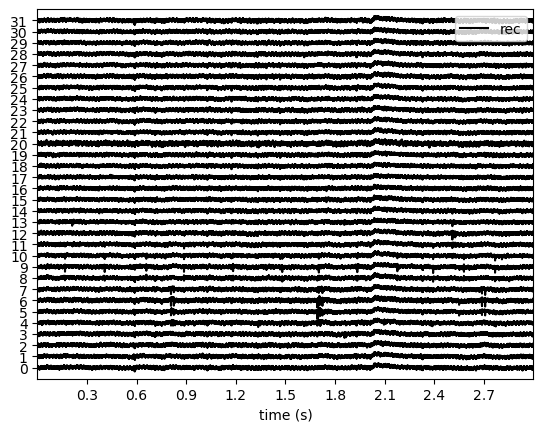

In [6]:
_ = sw.plot_traces(recording_with_lfp, time_range=[0,3], show_channel_ids=True)

## 2. Filtering with low cutoff frequencies : the problem

### Try to extract LFPs using a bandpass filter with a low highpass cutoff (1 Hz).
This will demonstrate a common issue

In [7]:
# Try to filter with 1 Hz highpass
try:
    recording_lfp_1hz = spre.bandpass_filter(
        recording_with_lfp, freq_min=1.0, freq_max=300.0
    )
except Exception as e:
    print(f"Error message:\n{str(e)}")

Error message:
The freq_min (1.0 Hz) is too low and may cause artifacts during chunk processing. You can set 'ignore_low_freq_error=True' to bypass this error, but make sure you understand the implications. It is recommended to use large chunks when processing/saving your filtered recording to minimize IO overhead.Refer to this documentation on LFP filtering and chunking artifacts for more details: https://spikeinterface.readthedocs.io/en/latest/forhowto/plot_extract_lfps.html. 


**Why does this fail?**

The error always occurs in SpikeInterface when highpass filtering below 100 Hz, to remind the user that they need to be careful. Filters with very low cutoff frequencies have long impulse responses, which require larger margins to avoid edge artifacts between chunks.

The filter length (and required margin) scales inversely with the highpass frequency. A 1 Hz highpass filter requires a margin of several seconds, while a 300 Hz highpass (for spike extraction) only needs a few milliseconds.

*This error is to inform the user that extra care should be used when dealing with LFP signals!*

## 3. Understanding chunking and margins

SpikeInterface processes recordings in chunks to handle large datasets efficiently. Each chunk needs a “margin” (extra samples at the edges) to avoid edge artifacts when filtering. Let’s demonstrate this by saving the filtered data with different chunking strategies.

We can explicitly ignore the previous error, but let’s make sure we understand what is happening.

In [8]:
recording_filt = spre.bandpass_filter(
    recording_with_lfp, freq_min=1.0, freq_max=300.0, ignore_low_freq_error=True
)

When retrieving traces, extra samples will be retrieved at the left and right edges. By default, the filter function will set a margin to 5x the sampling period associated to freq_min. So for a 1 Hz cutoff frequency, the margin will be 5 seconds!

In [9]:
margin_in_s = recording_filt.margin_samples / recording_with_lfp.sampling_frequency
print(f"Margin in seconds: {margin_in_s}")

Margin in seconds: 5.0


This effectively means that if we plot 1-s snippet of traces, a total of 11 s will actually be read and filtered. Hence the computational “overhead” is very large. Note that the margin can be overridden with the margin_ms argument, **but we do not recommend changing it**.

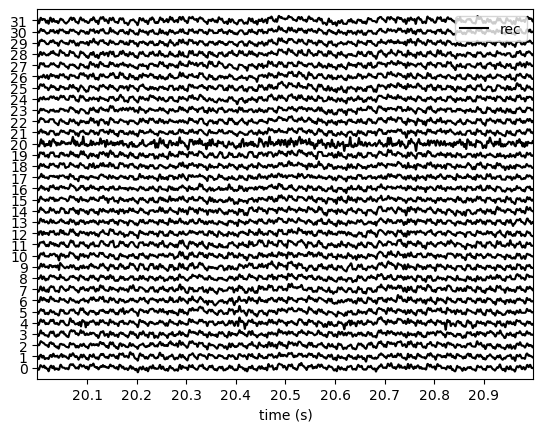

In [10]:
_ = sw.plot_traces(recording_filt, time_range=[20, 21], show_channel_ids=True)

A warning tells us that what we are doing is not optimized, since in order to get the requested traces the margin “overhead” is very large.

If we ask or plot longer snippets, the warning is not displayed.

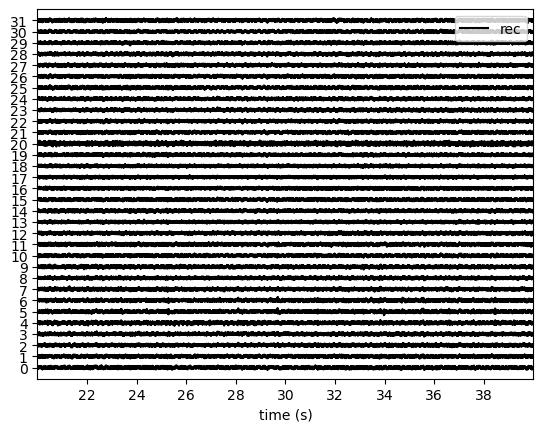

In [11]:
_ = sw.plot_traces(recording_filt, time_range=[20, 40], show_channel_ids=True, vspacing_factor=3)

## 4. Quantification and visualization of the artifacts

Let’s extract the traces and visualize the differences between chunking strategies. We’ll focus on the chunk boundaries where artifacts appear.

In [12]:
margins_ms = [5000, 10000]  # in milliseconds
chunk_durations = ["30s", "60s", "90s"]  # in seconds

The best we can do is to save the full recording in one chunk. This will cause no artifacts and chunking effects, but in practice it’s not possible due to the duration and number of channels of most setups.

Since in this toy case we have a single channel 1-min recording, we can use this as “optimal”.

In [13]:
t_start_optimal = time.perf_counter()

recording_optimal = recording_filt.save(
    folder="./cached/own_data/sp1_01/optimal", # should change to a directory that has a name of the recording currently analyzed, e.g., sp1_01
    chunk_duration="300s",
    progress_bar=False,
    overwrite=True,
    njobs=4
)

time_optimal = time.perf_counter() - t_start_optimal

print(recording_optimal)
print(f"Optimal recording processing time: {time_optimal:.2f} seconds")

write_binary 
engine=process - n_jobs=1 - samples_per_chunk=6,000,000 - chunk_memory=366.21 MiB - total_memory=366.21 MiB - chunk_duration=300.00s (5.00 minutes)
BinaryFolderRecording: 32 channels - 20.0kHz - 1 segments - 3,599,280 samples 
                       179.96s (3.00 minutes) - int16 dtype - 219.68 MiB
Optimal recording processing time: 4.95 seconds


Now we can do the same wiht our various options

In [14]:
recordings_chunked = {}

for margin_ms in margins_ms:
    for chunk_duration in chunk_durations:
        print(f"Margin ms: {margin_ms}, Chunk duration: {chunk_duration}")
        t_start = time.perf_counter()
        recording_chunk = spre.bandpass_filter(
            recording_with_lfp,
            freq_min=1.0,
            freq_max=300.0,
            margin_ms=margin_ms,
            ignore_low_freq_error=True
        )
        recording_chunk = recording_chunk.save(
            folder=f"./cached/own_data/sp1_01//margin_{margin_ms}_chunk_{chunk_duration}",
            chunk_duration=chunk_duration,
            verbose = False,
            progress_bar=False,
            overwrite=True,
            njobs=4
        )
        t_stop = time.perf_counter()
        result_dict = {"recording": recording_chunk, "time": t_stop - t_start}
        recordings_chunked[(margin_ms, chunk_duration)] = result_dict

Margin ms: 5000, Chunk duration: 30s
Margin ms: 5000, Chunk duration: 60s
Margin ms: 5000, Chunk duration: 90s
Margin ms: 10000, Chunk duration: 30s
Margin ms: 10000, Chunk duration: 60s
Margin ms: 10000, Chunk duration: 90s


In [15]:
print(result_dict)

{'recording': BinaryFolderRecording: 32 channels - 20.0kHz - 1 segments - 3,599,280 samples 
                       179.96s (3.00 minutes) - int16 dtype - 219.68 MiB, 'time': 3.363693375024013}


The artifacts do not depend on chunk size, but for smaller chunk sizes, these artifacts will happen more often. In addition, the margin “overhead” will make processing slower. Let’s quantify these concepts by computing the overall absolute error with respect to the optimal case and processing time.

In [16]:
trace_plotted = False
traces_optimal = recording_optimal.get_traces()
data = {"margin": [], "chunk": [],"error": [], "time": []}

for recording_key, recording_dict in recordings_chunked.items():
    recording_chunk = recording_dict["recording"]
    time = recording_dict["time"]
    margin, chunk = recording_key
    traces_chunk = recording_chunk.get_traces()
    error = np.sum(np.abs(traces_optimal - traces_chunk))
    data["margin"].append(margin)
    data["chunk"].append(chunk)
    data["error"].append(error)
    data["time"].append(time)

df = pd.DataFrame(data)

In [17]:
print(recordings_chunked)

{(5000, '30s'): {'recording': BinaryFolderRecording: 32 channels - 20.0kHz - 1 segments - 3,599,280 samples 
                       179.96s (3.00 minutes) - int16 dtype - 219.68 MiB, 'time': 3.52859741600696}, (5000, '60s'): {'recording': BinaryFolderRecording: 32 channels - 20.0kHz - 1 segments - 3,599,280 samples 
                       179.96s (3.00 minutes) - int16 dtype - 219.68 MiB, 'time': 3.7892081659520045}, (5000, '90s'): {'recording': BinaryFolderRecording: 32 channels - 20.0kHz - 1 segments - 3,599,280 samples 
                       179.96s (3.00 minutes) - int16 dtype - 219.68 MiB, 'time': 3.5684562500100583}, (10000, '30s'): {'recording': BinaryFolderRecording: 32 channels - 20.0kHz - 1 segments - 3,599,280 samples 
                       179.96s (3.00 minutes) - int16 dtype - 219.68 MiB, 'time': 4.664253374910913}, (10000, '60s'): {'recording': BinaryFolderRecording: 32 channels - 20.0kHz - 1 segments - 3,599,280 samples 
                       179.96s (3.00 minutes) - 

In [18]:
print(recordings_chunked.keys())

dict_keys([(5000, '30s'), (5000, '60s'), (5000, '90s'), (10000, '30s'), (10000, '60s'), (10000, '90s')])


In [19]:
print(data)

{'margin': [5000, 5000, 5000, 10000, 10000, 10000], 'chunk': ['30s', '60s', '90s', '30s', '60s', '90s'], 'error': [np.int64(4388), np.int64(1718), np.int64(845), np.int64(0), np.int64(0), np.int64(0)], 'time': [3.52859741600696, 3.7892081659520045, 3.5684562500100583, 4.664253374910913, 3.748785167001188, 3.363693375024013]}


Now let’s visualize the error and processing time for different margin and chunk size combinations

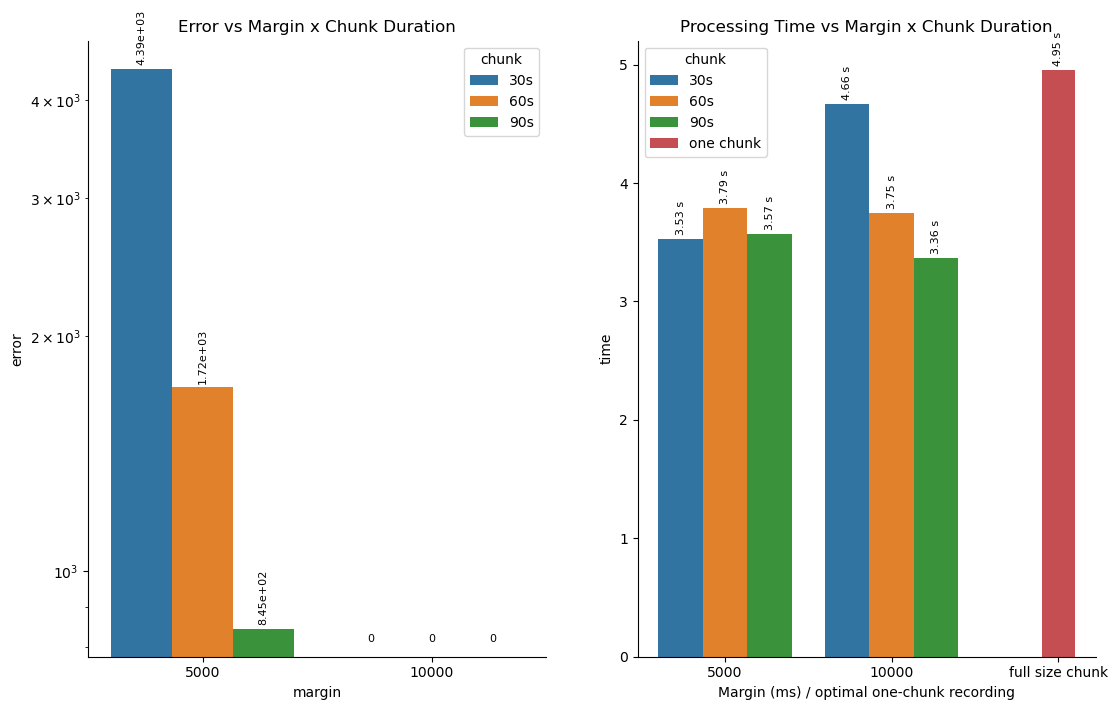

In [20]:
fig, axs = plt.subplots(ncols=2, figsize=(13, 8))
sns.barplot(data=data, x="margin", y="error", hue="chunk", ax=axs[0])
axs[0].set_yscale("log")
axs[0].set_title("Error vs Margin x Chunk Duration")

for container in axs[0].containers:
    for bar in container:
        value = bar.get_height()
        value_adjusted = value * 1.01 # for readability
        x_position = bar.get_x() + bar.get_width() / 2
        if value == 0:
            axs[0].text(
                x_position,
                0.02,
                "0",
                transform=axs[0].get_xaxis_transform(),
                ha="center",
                va="bottom",
                fontsize=8,
            )
        else:
            axs[0].text(
                x_position,
                value_adjusted,
                f"{value:.2e}",
                ha="center",
                va="bottom",
                rotation=90,
                fontsize=8,
                clip_on=False,
            )

# Plot the regular chunked recordings with Seaborn.
df_chunked_time = df[df["chunk"].isin(chunk_durations)]
margin_order = margins_ms + ["full size chunk"]
sns.barplot(
    data=df_chunked_time,
    x="margin",
    y="time",
    hue="chunk",
    order=margins_ms,
    ax=axs[1],
)

# Draw the one-chunk optimal recording at the center of its own x category.
optimal_bar = axs[1].bar(
    x=len(margins_ms),
    height=time_optimal,
    width=0.2,
    color=sns.color_palette("deep", n_colors=4)[3],
    label="one chunk",
    align="center",
)
axs[1].set_xticks(range(len(margin_order)), labels=[str(value) for value in margin_order])
axs[1].set_title("Processing Time vs Margin x Chunk Duration")
axs[1].set_xlabel("Margin (ms) / optimal one-chunk recording")
axs[1].legend(title="chunk")

for container in axs[1].containers:
    labels = axs[1].bar_label(container, fmt="%.2f s", padding=3, fontsize=8)
    for label in labels:
        label.set_rotation(90)
        label.set_verticalalignment("bottom")
        label.set_horizontalalignment("center")

sns.despine(fig)

## Summary
1. **Low-frequency filters require special care**: Filters with low cutoff frequencies (< 10 Hz) have long impulse responses that require large margins to avoid edge artifacts.

2. **Chunking artifacts are real**: When processing data in chunks, insufficient margins lead to visible discontinuities and errors at chunk boundaries.

3. **The solution: large chunks and large**: For LFP extraction (1-300 Hz), use: - Chunk size: 30-60-90 seconds - Margin size: 5-10 seconds (for 1 Hz highpass) (use defaults - 5s for 1 Hz highpass!) - This is less memory-efficient but more accurate

4. **Downsample after filtering**: After bandpass filtering, downsample to reduce data size (e.g., to 1-2.5 kHz for 300 Hz max frequency).

5. **Trade-offs**: There’s always a trade-off between computational efficiency (smaller chunks, less memory) and accuracy (larger chunks, fewer artifacts). For LFP analysis, accuracy should take priority.

**When processing your own data:**

* If you have memory constraints, use the largest chunk size your system can handle

* Always verify your filtering parameters on a small test segment first

* Consider the lowest frequency component you want to preserve when setting margins

* Save the processed LFP data to disk to avoid recomputing

## Analysis of LFP Data

### Downsampling after filtering

I will use the single-chunk version and the 90s chunk - 5s and 10s margin versions for further analysis

In [24]:
# Downsampling the filtered data to 2.5 kHz for LFP analysis
# Resampling is done with a margin of 100ms by default in SI Preprocessing.
# First, the "optimal" one-chunk recording
recording_optimal_downsampled = spre.resample(recording_optimal, resample_rate=2500) 
recording_optimal_downsampled = recording_optimal_downsampled.save(
    folder="./cached/own_data/sp1_01/optimal_downsampled", # should change to a directory that has a name of the recording currently analyzed, e.g., sp1_01
    chunk_duration="300s",
    progress_bar=False,
    overwrite=True,
    njobs=4
)
print(recording_optimal_downsampled)

# Next the 90s chunked recording with 5000 ms margin
recording_90s_5000ms_downsampled = spre.resample(recordings_chunked[(5000, "90s")]["recording"], resample_rate=2500)
recording_90s_5000ms_downsampled = recording_90s_5000ms_downsampled.save(
    folder="./cached/own_data/sp1_01/margin_5000_chunk_90s_downsampled", # should change to a directory that has a name of the recording currently analyzed, e.g., sp1_01
    chunk_duration="90s",
    progress_bar=False,
    overwrite=True,
    njobs=4
)
print(recording_90s_5000ms_downsampled)

# Next the 90s chunked recording with 10000 ms margin
recording_90s_10000ms_downsampled = spre.resample(recordings_chunked[(10000, "90s")]["recording"], resample_rate=2500)
recording_90s_10000ms_downsampled = recording_90s_10000ms_downsampled.save(
    folder="./cached/own_data/sp1_01/margin_10000_chunk_90s_downsampled", # should change to a directory that has a name of the recording currently analyzed, e.g., sp1_01
    chunk_duration="90s",
    progress_bar=False,
    overwrite=True,
    njobs=4
)
print(recording_90s_10000ms_downsampled)

write_binary 
engine=process - n_jobs=1 - samples_per_chunk=750,000 - chunk_memory=45.78 MiB - total_memory=45.78 MiB - chunk_duration=300.00s (5.00 minutes)
BinaryFolderRecording: 32 channels - 2500.0Hz - 1 segments - 449,910 samples 
                       179.96s (3.00 minutes) - int16 dtype - 27.46 MiB
write_binary 
engine=process - n_jobs=1 - samples_per_chunk=225,000 - chunk_memory=13.73 MiB - total_memory=13.73 MiB - chunk_duration=90.00s (1.50 minutes)
BinaryFolderRecording: 32 channels - 2500.0Hz - 1 segments - 449,910 samples 
                       179.96s (3.00 minutes) - int16 dtype - 27.46 MiB
write_binary 
engine=process - n_jobs=1 - samples_per_chunk=225,000 - chunk_memory=13.73 MiB - total_memory=13.73 MiB - chunk_duration=90.00s (1.50 minutes)
BinaryFolderRecording: 32 channels - 2500.0Hz - 1 segments - 449,910 samples 
                       179.96s (3.00 minutes) - int16 dtype - 27.46 MiB


## Visualizing the filtered signals

In [31]:
n_ch = 32
recording_optimal_downsampled.set_property("gain_to_uV", [1.0] * n_ch)
recording_optimal_downsampled.set_property("offset_to_uV", [0.0] * n_ch)
recording_90s_5000ms_downsampled.set_property("gain_to_uV", [1.0] * n_ch)
recording_90s_5000ms_downsampled.set_property("offset_to_uV", [0.0] * n_ch)
recording_90s_10000ms_downsampled.set_property("gain_to_uV", [1.0] * n_ch)
recording_90s_10000ms_downsampled.set_property("offset_to_uV", [0.0] * n_ch)

Text(0.5, 0, 'Time (s)')

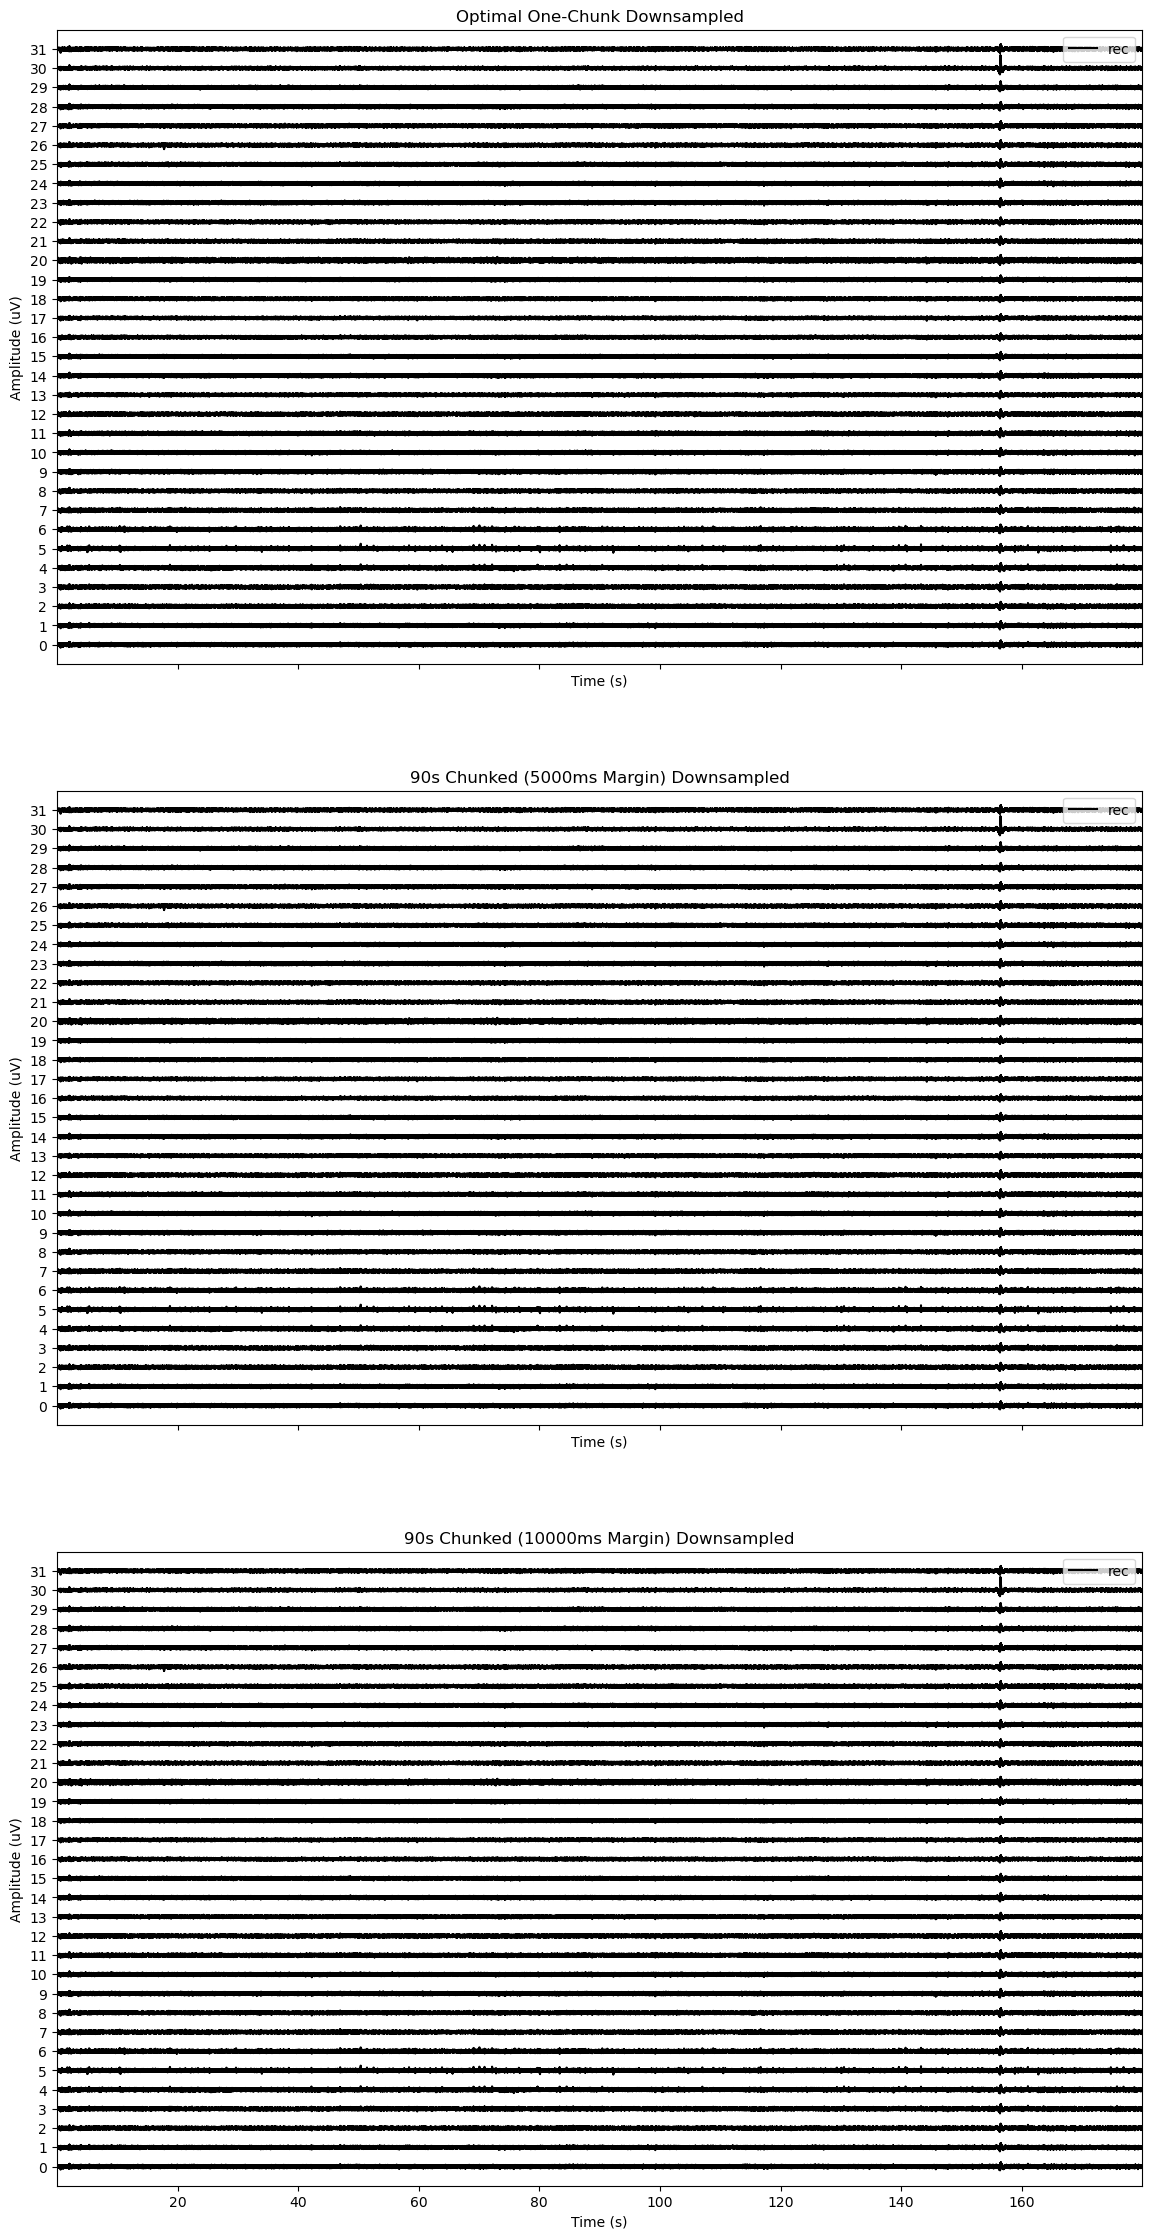

In [38]:
# Plot the downsampled recordings to verify the results
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(14, 28), sharex=True)
sw.plot_traces(recording_optimal_downsampled, ax=axs[0], return_in_uV=True, show_channel_ids=True, time_range=[0, 179.96])
axs[0].set_title("Optimal One-Chunk Downsampled")
axs[0].set_ylabel("Amplitude (uV)")
axs[0].set_xlabel("Time (s)")
sw.plot_traces(recording_90s_5000ms_downsampled, ax=axs[1], return_in_uV=True, show_channel_ids=True, time_range=[0, 179.96])
axs[1].set_title("90s Chunked (5000ms Margin) Downsampled")
axs[1].set_ylabel("Amplitude (uV)")
axs[1].set_xlabel("Time (s)")
sw.plot_traces(recording_90s_10000ms_downsampled, ax=axs[2], return_in_uV=True, show_channel_ids=True, time_range=[0, 179.96])
axs[2].set_title("90s Chunked (10000ms Margin) Downsampled")
axs[2].set_ylabel("Amplitude (uV)")
axs[2].set_xlabel("Time (s)")

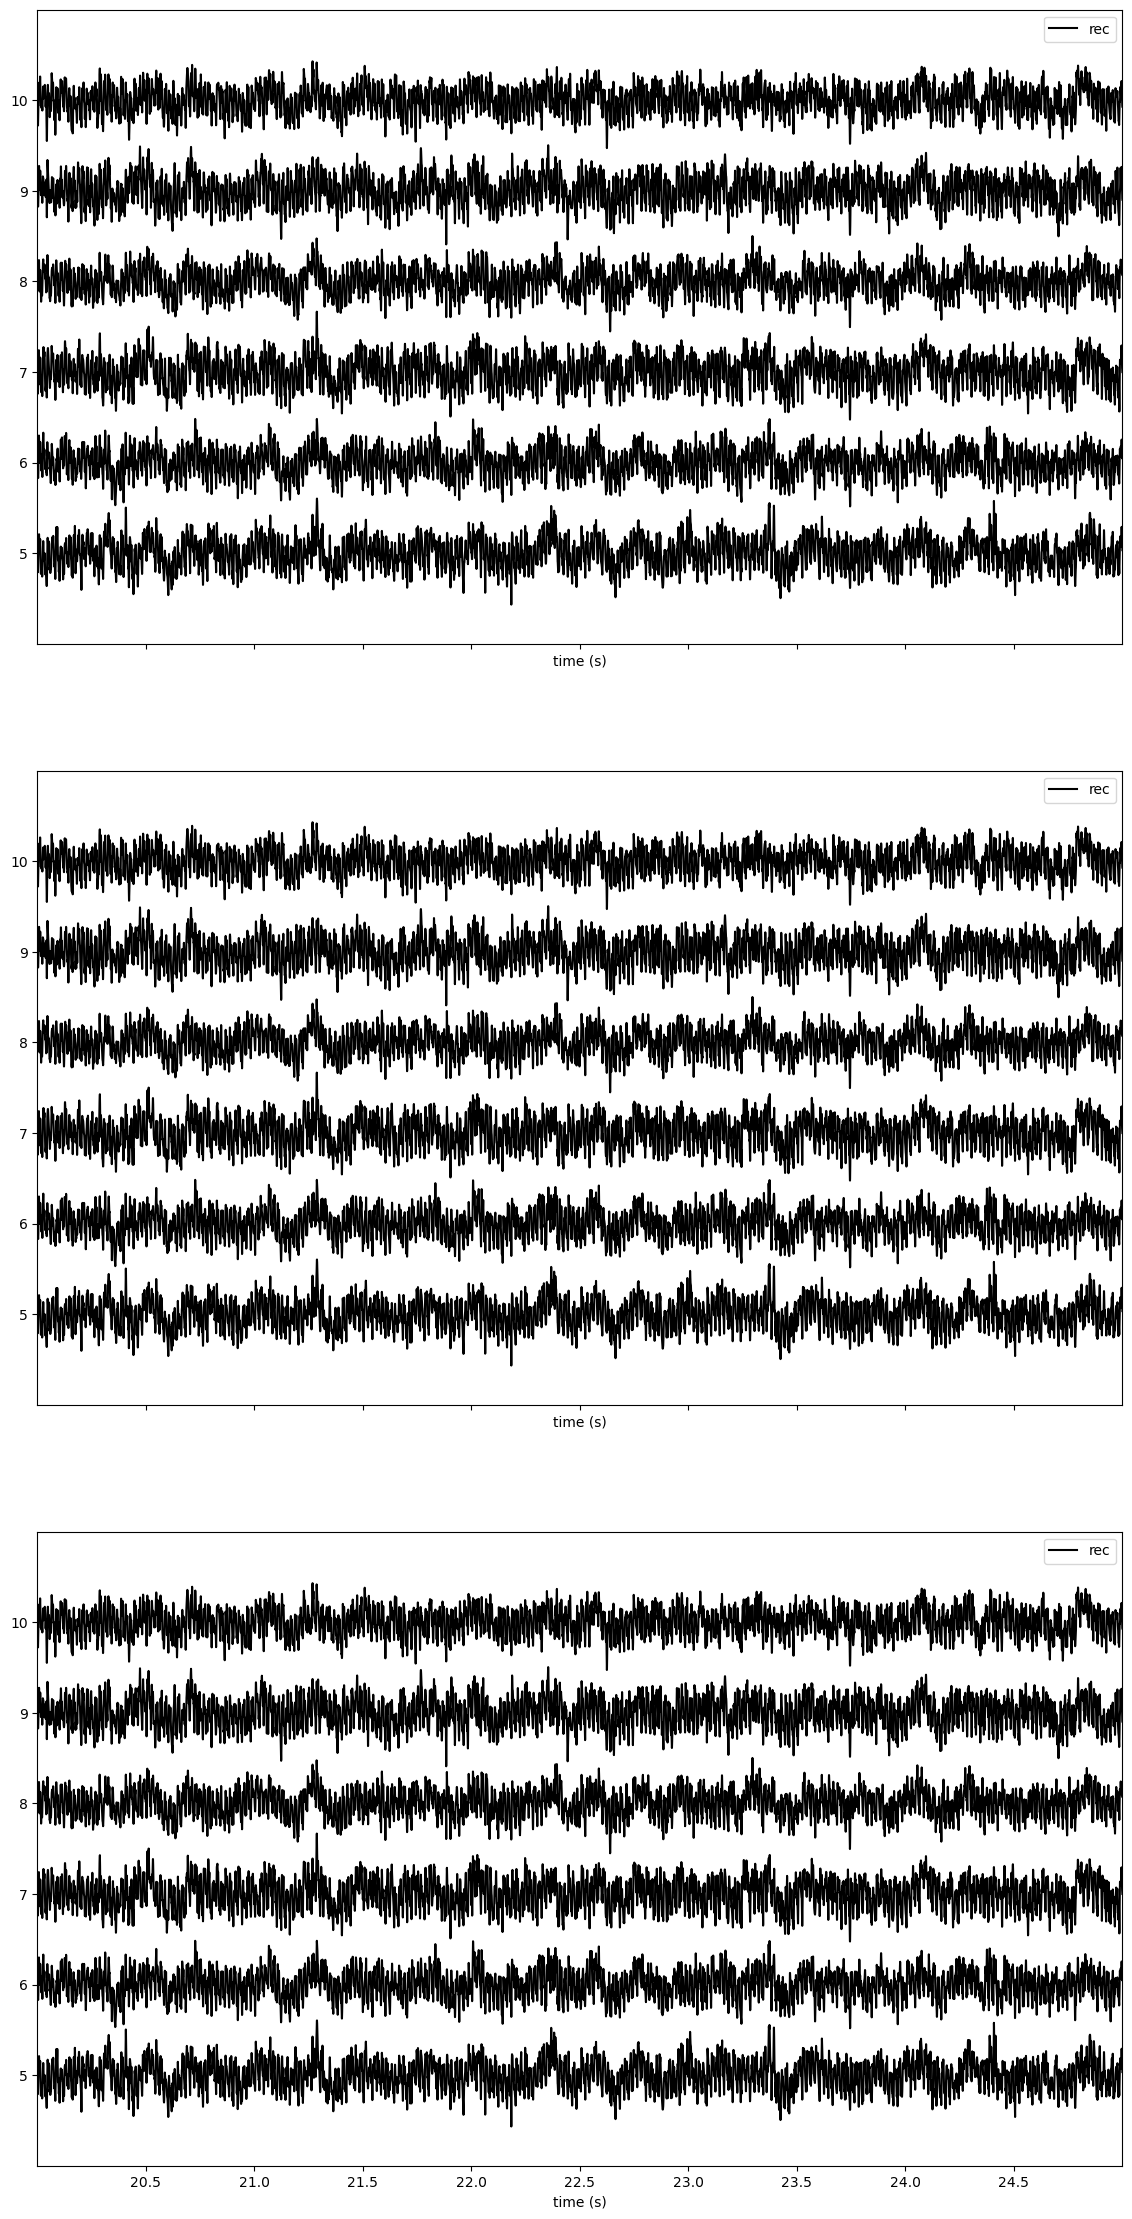

In [ ]:
# Plot a few channels only, with a time range of 20 to 25 seconds, to compare the downsampled recordings
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(14, 28), sharex=True)
channels_to_plot = [5, 6, 7, 8, 9, 10]  # Specify the channels you want to plot
sw.plot_traces(recording_optimal_downsampled, ax=axs[0], return_in_uV=True, show_channel_ids=True, time_range=[20, 25], channel_ids=channels_to_plot)
sw.plot_traces(recording_90s_5000ms_downsampled, ax=axs[1], return_in_uV=True, show_channel_ids=True, time_range=[20, 25], channel_ids=channels_to_plot)
sw.plot_traces(recording_90s_10000ms_downsampled, ax=axs[2], return_in_uV=True, show_channel_ids=True, time_range=[20, 25], channel_ids=channels_to_plot)